In [299]:
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt

def load_scenarios(demand_csv, capacity_csv):
    # ----------------------------
    # Helpers
    # ----------------------------
    def clean_cols(df):
        return (
            df.columns
            .str.strip()
            .str.lower()
            .str.replace(" ", "_")
        )

    def parse_efficiency(s):
        s = (
            s.astype(str)
            .str.rstrip("%")
            .astype(float)
        )
        s.loc[s > 1] /= 100
        return s

    # ----------------------------
    # Load data
    # ----------------------------
    ddf = pd.read_csv(demand_csv)
    cdf = pd.read_csv(capacity_csv)

    ddf.columns = clean_cols(ddf)
    cdf.columns = clean_cols(cdf)

    # ----------------------------
    # Demand scenarios
    # ----------------------------
    demand_scenarios = {}

    for scenario, sdf in ddf.groupby("scenario"):
        sdf = sdf.copy().reset_index(drop=True)

        # preserve order (or enforce if needed)
        quarters = sdf["quarter"].tolist()

        demand = sdf["demand"].astype(float).to_numpy()
        target_woh = sdf["target_woh"].astype(float).to_numpy()
        target_inventory = demand * target_woh / 13

        nit_lb_pct = sdf["nit_lb_pct"].astype(float).to_numpy()
        nit_ub_pct = sdf["nit_ub_pct"].astype(float).to_numpy()

        # inventory_0 from first non-null
        if sdf["inventory_0"].notna().any():
            inventory_0 = float(sdf["inventory_0"].dropna().iloc[0])
        else:
            raise ValueError(f"No inventory_0 found for {scenario}")

        demand_scenarios[scenario] = {
            "quarters": quarters,
            "demand": demand,
            "target_inventory": target_inventory,
            "nit_lb_pct": nit_lb_pct,
            "nit_ub_pct": nit_ub_pct,
            "inventory_0": inventory_0,
            "raw": sdf,
        }

    # ----------------------------
    # Capacity scenarios
    # ----------------------------
    cdf["efficiency"] = parse_efficiency(cdf["efficiency"])

    capacity_scenarios = {}

    for scenario, sdf in cdf.groupby("scenario"):
        sdf = sdf.copy().reset_index(drop=True)

        quarters = list(dict.fromkeys(sdf["quarter"]))
        sites = list(dict.fromkeys(sdf["site"]))

        # capacity calculation
        sdf["capacity_units"] = (
            sdf["minutes_per_tech"]
            * sdf["max_number_of_techs"]
            * sdf["efficiency"]
            / sdf["time_standard"]
        )

        capacity = (
            sdf.pivot(index="quarter", columns="site", values="capacity_units")
            .reindex(index=quarters, columns=sites)
            .astype(float)
        )

        max_hc = (
            sdf.pivot(index="quarter", columns="site", values="max_number_of_techs")
            .reindex(index=quarters, columns=sites)
            .astype(float)
        )

        min_share = (
            sdf.pivot(index="quarter", columns="site", values="min_share")
            .reindex(index=quarters, columns=sites)
            .fillna(0.0)
            .astype(float)
        )

        # Q0 initial HC
        current_hc = (
            sdf.dropna(subset=["current_hc"])
            .drop_duplicates("site")
            .set_index("site")["current_hc"]
            .reindex(sites)
            .fillna(0.0)
            .astype(float)
        )

        capacity_scenarios[scenario] = {
            "quarters": quarters,
            "sites": sites,
            "capacity": capacity,
            "max_hc": max_hc,
            "min_share": min_share,
            "current_hc": current_hc,
            "raw": sdf,
        }

    return demand_scenarios, capacity_scenarios

In [300]:



def solve_supply_plan_hc_stability(
    demand_dict: dict,
    capacity_dict: dict,
    epsilon: float = 1.0,
    smoothing_weight: float = 1.0,
    solver=cp.OSQP,
    verbose: bool = False,
    make_plots: bool = True,
):
    """
    Rough-cut supply optimizer with:
      - H[s,t] = headcount decision variable
      - p[s,t] = production decision variable
      - inventory constrained to NIT bands
      - stability objective based on headcount changes, not build changes

    Objective:
        minimize smoothing_weight * HC_stability
               + epsilon * NIT_centering
    """

    # ----------------------------
    # Demand inputs
    # ----------------------------
    quarters = list(demand_dict["quarters"])
    demand = np.asarray(demand_dict["demand"], dtype=float)
    target_inventory = np.asarray(demand_dict["target_inventory"], dtype=float)
    nit_lb_pct = np.asarray(demand_dict["nit_lb_pct"], dtype=float)
    nit_ub_pct = np.asarray(demand_dict["nit_ub_pct"], dtype=float)
    inventory_0 = float(demand_dict["inventory_0"])

    T = len(quarters)

    # ----------------------------
    # Capacity / HC inputs
    # ----------------------------
    raw = capacity_dict["raw"].copy()
    raw.columns = (
        raw.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

    sites = list(capacity_dict["sites"])
    S = len(sites)

    capacity_quarters = list(capacity_dict["quarters"])

    if quarters != capacity_quarters:
        raise ValueError(
            "Demand and capacity quarters do not match.\n"
            f"Demand quarters:   {quarters}\n"
            f"Capacity quarters: {capacity_quarters}"
        )

    # These should already exist in capacity_dict from ingestion
    max_hc = (
        capacity_dict["max_hc"]
        .reindex(index=quarters, columns=sites)
        .astype(float)
    )

    min_share = (
        capacity_dict["min_share"]
        .reindex(index=quarters, columns=sites)
        .fillna(0.0)
        .astype(float)
    )

    current_hc = (
        capacity_dict["current_hc"]
        .reindex(sites)
        .fillna(0.0)
        .astype(float)
    )

    # ----------------------------
    # Build units-per-HC matrix
    # ----------------------------
    # If efficiency came in as 50%, make sure it is decimal
    raw["efficiency"] = (
        raw["efficiency"]
        .astype(str)
        .str.rstrip("%")
        .astype(float)
    )
    raw.loc[raw["efficiency"] > 1, "efficiency"] /= 100

    raw["units_per_hc"] = (
        raw["minutes_per_tech"]
        * raw["efficiency"]
        / raw["time_standard"]
    )

    units_per_hc = (
        raw.pivot(
            index="quarter",
            columns="site",
            values="units_per_hc"
        )
        .reindex(index=quarters, columns=sites)
        .astype(float)
    )

    units_per_hc_vals = units_per_hc.to_numpy().T  # S x T
    max_hc_vals = max_hc.to_numpy().T             # S x T

    # Decision variables
    # ----------------------------
    # H[s,t] = assigned HC
    H = cp.Variable((S, T), nonneg=True)

    # p[s,t] = production units
    p = cp.Variable((S, T), nonneg=True)

    # I[t] = ending inventory
    I = cp.Variable(T)

    total_prod = cp.sum(p, axis=0)

    # ----------------------------
    # Constraints
    # ----------------------------
    constraints = []

    # Inventory balance
    constraints.append(I[0] == inventory_0 + total_prod[0] - demand[0])

    for t in range(1, T):
        constraints.append(I[t] == I[t - 1] + total_prod[t] - demand[t])

    # NIT bounds
    nit_lb = nit_lb_pct * target_inventory
    nit_ub = nit_ub_pct * target_inventory

    constraints += [
        I >= nit_lb,
        I <= nit_ub,
    ]

    # HC upper bounds
    constraints.append(H <= max_hc_vals)

    # Production limited by HC-derived capacity
    constraints.append(
        p == cp.multiply(units_per_hc_vals, H)
    )

    # Minimum site share constraints
    for s, site in enumerate(sites):
        alpha = min_share[site].to_numpy()
        constraints.append(
            p[s, :] >= cp.multiply(alpha, total_prod)
        )

    # ----------------------------
    # HC Laplacian stability objective
    # ----------------------------
    H0 = current_hc.to_numpy().reshape(S, 1)

    H_full = cp.hstack([
        H0,
        H,
    ])

    # First-difference matrix: T x (T + 1)
    D = np.zeros((T, T + 1))

    for t in range(T):
        D[t, t] = -1
        D[t, t + 1] = 1

    hc_diffs = H_full @ D.T

    stability_objective = cp.sum_squares(hc_diffs)

    # ----------------------------
    # NIT centering objective
    # ----------------------------
    nit_centering_objective = cp.sum_squares(I - target_inventory)

    objective = cp.Minimize(
        smoothing_weight * stability_objective
        + epsilon * nit_centering_objective
    )

    problem = cp.Problem(objective, constraints)
    problem.solve(solver=solver, verbose=verbose)

    if problem.status not in {"optimal", "optimal_inaccurate"}:
        raise RuntimeError(f"Solve failed with status: {problem.status}")

    # ----------------------------
    # Outputs
    # ----------------------------
    production_by_site = pd.DataFrame(
        p.value.T,
        index=quarters,
        columns=sites,
    )

    headcount_by_site = pd.DataFrame(
        H.value.T,
        index=quarters,
        columns=sites,
    )

    max_capacity_units = units_per_hc * max_hc
    used_capacity_units = production_by_site

    summary = pd.DataFrame(index=quarters)
    summary["Quarter"] = quarters
    summary["Demand"] = demand
    summary["Target_Inventory"] = target_inventory
    summary["Inventory_LB"] = nit_lb
    summary["Inventory_UB"] = nit_ub
    summary["Total_Production"] = np.asarray(total_prod.value).ravel()
    summary["Ending_Inventory"] = np.asarray(I.value).ravel()
    summary["NIT_Deviation"] = summary["Ending_Inventory"] - summary["Target_Inventory"]
    summary["NIT_Abs_Deviation"] = summary["NIT_Deviation"].abs()
    summary["Total_HC"] = headcount_by_site.sum(axis=1)
    summary["Total_Max_HC"] = max_hc.sum(axis=1)
    summary["Total_Max_Capacity_Units"] = max_capacity_units.sum(axis=1)
    summary["Capacity_Utilization"] = (
        summary["Total_Production"] / summary["Total_Max_Capacity_Units"]
    )

    stability_score = float(stability_objective.value)
    nit_centering_score = float(nit_centering_objective.value)

    weighted_stability_score = float(smoothing_weight * stability_score)
    weighted_nit_score = float(epsilon * nit_centering_score)

    # ----------------------------
    # Plots
    # ----------------------------
    if make_plots:
        x = np.arange(T)

        plt.figure(figsize=(10, 6))
        plt.bar(x, summary["Ending_Inventory"], alpha=0.65, label="Ending Inventory")
        plt.plot(x, summary["Total_Production"], marker="o", label="Total Build Plan")
        plt.plot(x, summary["Demand"], marker="o", linewidth=2, label="Demand")
        plt.plot(x, summary["Target_Inventory"], linestyle="--", linewidth=2, label="NIT")
        plt.plot(x, summary["Inventory_LB"], linestyle=":", linewidth=2, label="LCL")
        plt.plot(x, summary["Inventory_UB"], linestyle=":", linewidth=2, label="UCL")

        plt.xticks(x, quarters)
        plt.xlabel("Quarter")
        plt.ylabel("Units")
        plt.title("Inventory, Demand, and Build Plan by Quarter")
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 6))
        for site in sites:
            plt.plot(x, production_by_site[site], marker="o", label=f"{site} Build")
            plt.plot(x, max_capacity_units[site], linestyle=":", label=f"{site} Max Capacity")

        plt.xticks(x, quarters)
        plt.xlabel("Quarter")
        plt.ylabel("Units")
        plt.title("Build Plan by Site vs HC-Derived Capacity")
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 6))
        for site in sites:
            plt.plot(x, headcount_by_site[site], marker="o", label=f"{site} HC")
            plt.plot(x, max_hc[site], linestyle=":", label=f"{site} Max HC")

        plt.xticks(x, quarters)
        plt.xlabel("Quarter")
        plt.ylabel("Headcount")
        plt.title("Optimized Headcount by Site")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {
        "status": problem.status,
        "objective_value": problem.value,
        "epsilon": epsilon,

        "stability_score": stability_score,
        "nit_centering_score": nit_centering_score,
        "weighted_stability_score": weighted_stability_score,
        "weighted_nit_score": weighted_nit_score,

        "summary": summary,
        "production_by_site": production_by_site,
        "headcount_by_site": headcount_by_site,
        "units_per_hc": units_per_hc,
        "max_hc": max_hc,
        "max_capacity_units": max_capacity_units,
        "min_share": min_share,
    }

In [301]:
def run_epsilon_sweep(
    demand_dict,
    capacity_dict,
    epsilons,
    smoothing_weight=1.0,
):
    results = {}
    rows = []

    for eps in epsilons:
        r = solve_supply_plan_hc_stability(
            demand_dict=demand_dict,
            capacity_dict=capacity_dict,
            epsilon=eps,
            smoothing_weight=smoothing_weight,
            make_plots=False,
        )

        results[eps] = r

        rows.append({
            "epsilon": eps,
            "objective_value": r["objective_value"],

            # raw tradeoff scores
            "stability_score": r["stability_score"],
            "nit_centering_score": r["nit_centering_score"],

            # weighted contribution to objective
            "weighted_stability_score": r["weighted_stability_score"],
            "weighted_nit_score": r["weighted_nit_score"],

            # business-readable NIT metrics
            "avg_abs_nit_deviation": r["summary"]["NIT_Abs_Deviation"].mean(),
            "max_abs_nit_deviation": r["summary"]["NIT_Abs_Deviation"].max(),
            "ending_nit_deviation": r["summary"]["NIT_Deviation"].iloc[-1],
        })

    tradeoff_df = pd.DataFrame(rows)

    return results, tradeoff_df

In [302]:
epsilons = [0.001, 0.01, 0.1, 1]
ds,cs=load_scenarios('Project Mock Data - Demand and NIT (2).csv','Project Mock Data - Capacity (7).csv')

results, tradeoff_df = run_epsilon_sweep(
    demand_dict=ds["seasonal_peak_q4"],
    capacity_dict=cs["low_volume_seasonal"],
    epsilons=epsilons,
    smoothing_weight=1.0,
)

In [303]:
def plot_inventory_hc_epsilon_grid(results, epsilons):
    """
    4 rows x 2 columns:
      left  = inventory / NIT chart
      right = HC by site vs max HC
    """

    fig, axes = plt.subplots(
        nrows=len(epsilons),
        ncols=2,
        figsize=(14, 4 * len(epsilons)),
        sharex=False,
    )

    for row, eps in enumerate(epsilons):
        r = results[eps]
        df = r["summary"].copy()

        quarters = df["Quarter"].tolist()
        x = np.arange(len(df))

        # ----------------------------
        # Left: Inventory chart
        # ----------------------------
        ax_inv = axes[row, 0]

        ax_inv.bar(x, df["Ending_Inventory"], alpha=0.6, label="Ending Inventory", color='gray')
        ax_inv.plot(x, df["Target_Inventory"], linestyle="--", linewidth=2, label="NIT")
        ax_inv.fill_between(
            x,
            df["Inventory_LB"],
            df["Inventory_UB"],
            alpha=0.15,
            label="NIT Band",
            color='b'
        )
        ax_inv.plot(x, df["Demand"], marker="o", linewidth=1.5, label="Demand")
        ax_inv.plot(x, df["Total_Production"], marker="o", linewidth=1.5, label="Build Qty")

        ax_inv.set_title(f"ε = {eps} | Inventory / NIT")
        ax_inv.set_xticks(x)
        ax_inv.set_xticklabels(quarters)
        ax_inv.set_ylabel("Units")
        ax_inv.grid(True, alpha=0.25)

        # ----------------------------
        # Right: HC chart
        # ----------------------------
        ax_hc = axes[row, 1]

        ax_hc = axes[row, 1]
        
        hc = r["headcount_by_site"].copy()      # use actual decision variable
        max_hc = r["max_hc"].copy()
        
        sites = hc.columns.tolist()
        
        colors = plt.cm.tab10.colors  # or any colormap

        for i, site in enumerate(sites):
            color = colors[i % len(colors)]
        
            ax_hc.plot(
                x,
                hc[site],
                marker="o",
                linewidth=1.5,
                color=color,
                label=f"{site} HC"
            )
        
            ax_hc.plot(
                x,
                max_hc[site],
                linestyle=":",
                linewidth=1.5,
                color=color,
                label=f"{site} Max HC"
            )
        
        # unified y-axis scaling
        y_max = max(hc.to_numpy().max(), max_hc.to_numpy().max())
        ax_hc.set_ylim(0, 1.2 * y_max)
        
        ax_hc.set_title(f"ε = {eps} | HC by Site")
        ax_hc.set_xticks(x)
        ax_hc.set_xticklabels(quarters)
        ax_hc.set_ylabel("Headcount")
        ax_hc.grid(True, alpha=0.25)

    # Shared legends
    inv_handles, inv_labels = axes[0, 0].get_legend_handles_labels()
    hc_handles, hc_labels = axes[0, 1].get_legend_handles_labels()

    fig.legend(
        inv_handles,
        inv_labels,
        loc="lower left",
        bbox_to_anchor=(0.08, 0.01),
        ncol=3,
        title="Inventory Chart",
    )

    fig.legend(
        hc_handles,
        hc_labels,
        loc="lower right",
        bbox_to_anchor=(0.95, 0.01),
        ncol=3,
        title="HC Chart",
    )

    fig.suptitle("Inventory and HC Tradeoff by Epsilon", fontsize=16)

    fig.tight_layout(rect=[0, 0.08, 1, 0.96])
    plt.savefig('Demo.png')
    plt.show()

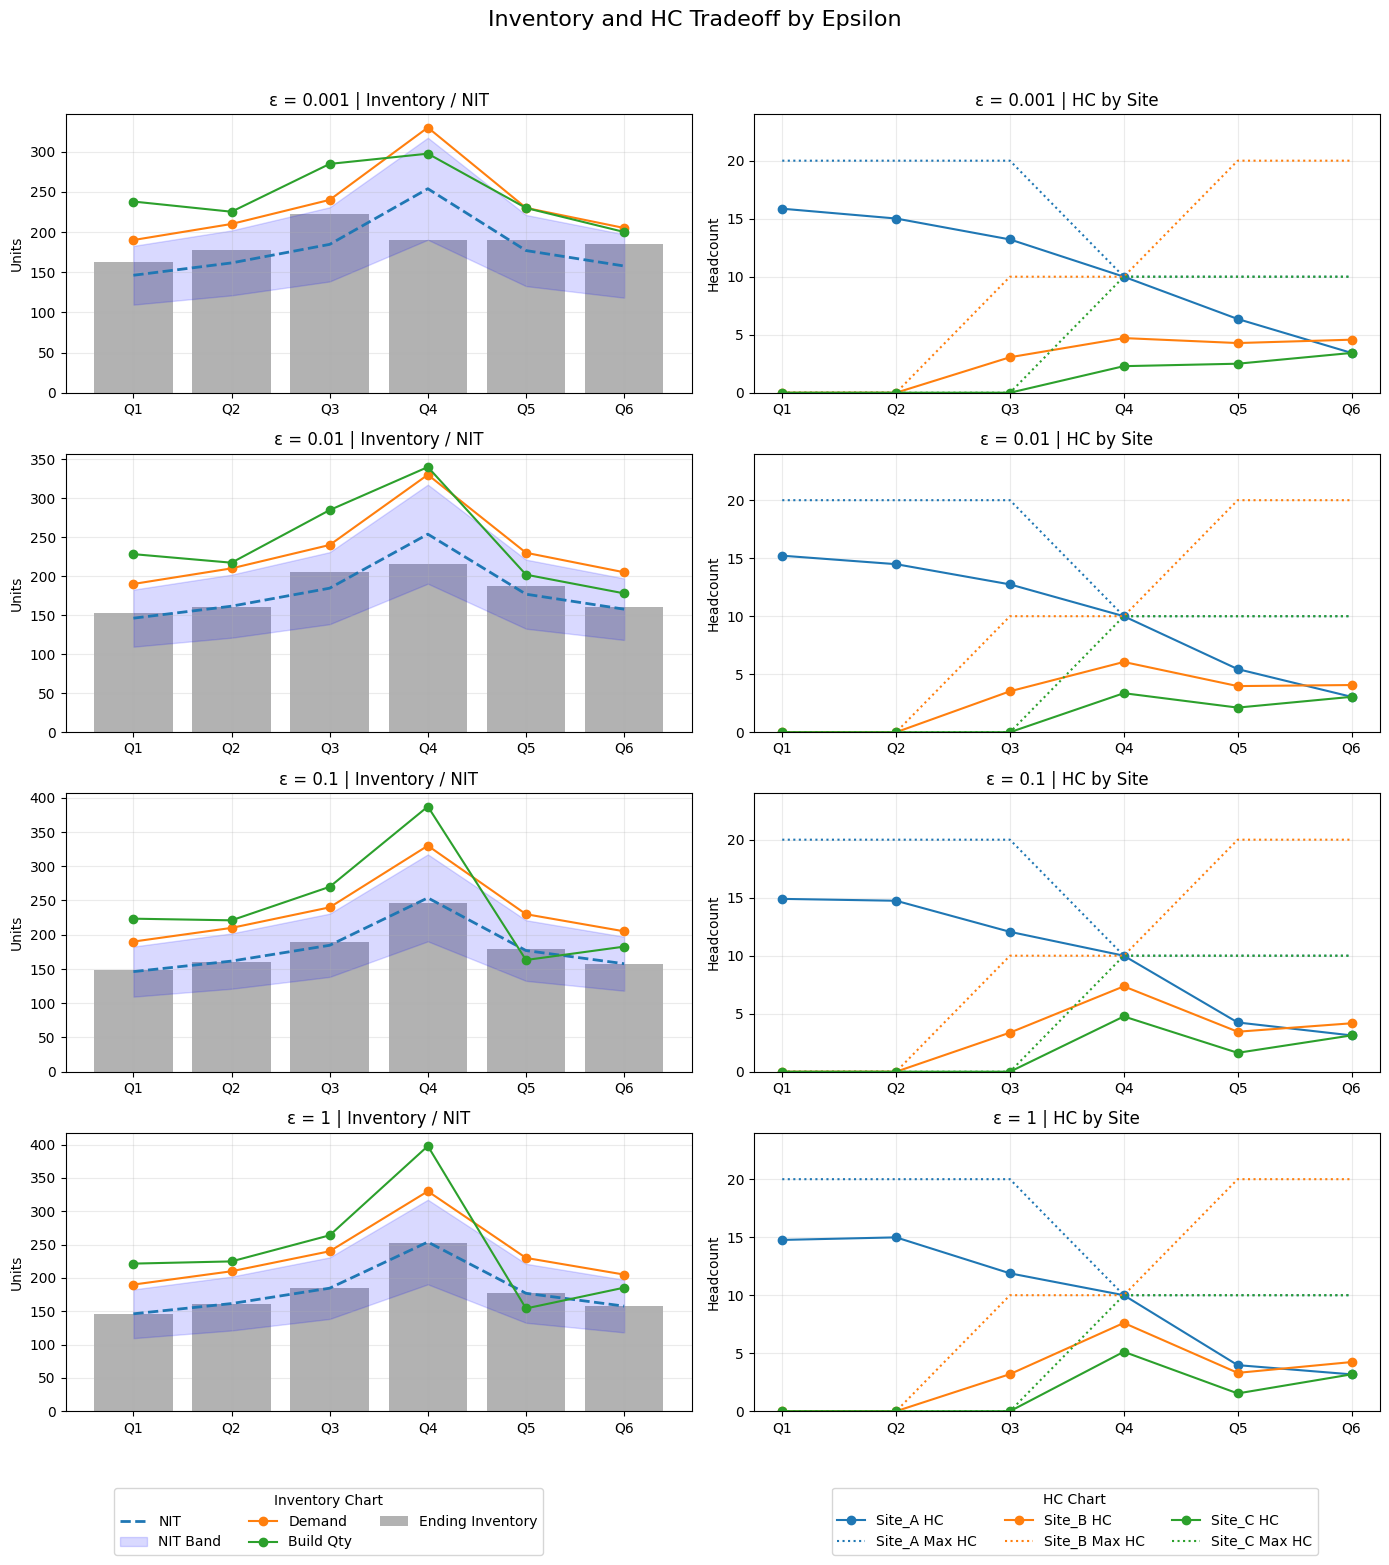

In [304]:
plot_inventory_hc_epsilon_grid(results, epsilons)

In [294]:
results[0.001]

{'status': 'optimal',
 'objective_value': np.float64(57.334930637595214),
 'epsilon': 0.001,
 'stability_score': 54.495566245970224,
 'nit_centering_score': 2839.364391624987,
 'weighted_stability_score': 54.495566245970224,
 'weighted_nit_score': 2.8393643916249873,
 'summary':    Quarter  Demand  Target_Inventory  Inventory_LB  Inventory_UB  \
 Q1      Q1   240.0        184.615385    156.923077    212.307692   
 Q2      Q2   210.0        161.538462    137.307692    185.769231   
 Q3      Q3   175.0        134.615385    114.423077    154.807692   
 Q4      Q4   190.0        146.153846    124.230769    168.076923   
 Q5      Q5   230.0        176.923077    150.384615    203.461538   
 Q6      Q6   270.0        207.692308    176.538462    238.846154   
 
     Total_Production  Ending_Inventory  NIT_Deviation  NIT_Abs_Deviation  \
 Q1        256.923075        156.923075     -27.692310          27.692310   
 Q2        198.097937        145.021010     -16.517452          16.517452   
 Q3  

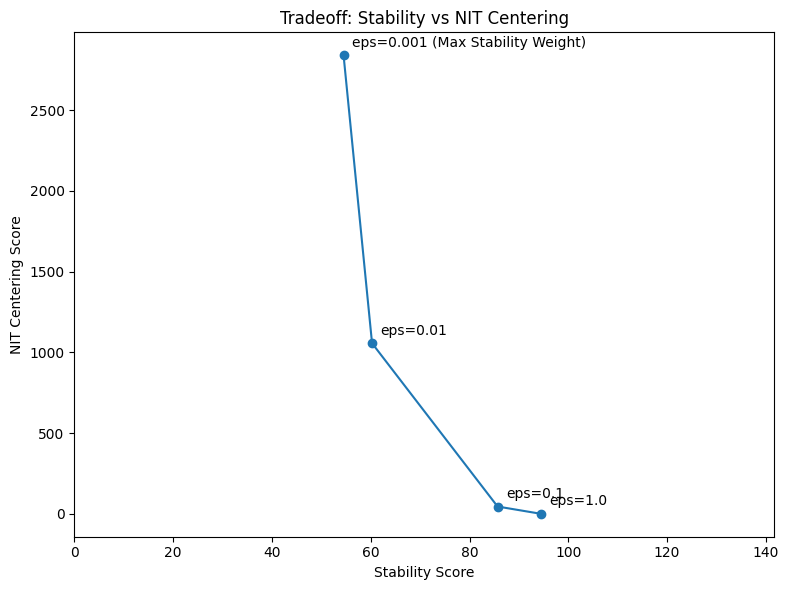

In [295]:
plt.figure(figsize=(8, 6))
plt.plot(
    tradeoff_df["stability_score"],
    tradeoff_df["nit_centering_score"],
    marker="o",
)

count=0
for _, row in tradeoff_df.iterrows():
    if count==0:
        name=f"eps={row['epsilon']} (Max Stability Weight)"
    elif count==7:
        name=f"eps={row['epsilon']} (Max Inventory Weight)"
    else:
        name=f"eps={row['epsilon']}"
    plt.annotate(
        name,
        (row["stability_score"], row["nit_centering_score"]),
        textcoords="offset points",
        xytext=(6, 6),
    )
    count+=1

plt.xlabel("Stability Score")
plt.xlim([0,1.5*max(tradeoff_df["stability_score"])])
plt.ylabel("NIT Centering Score")
plt.title("Tradeoff: Stability vs NIT Centering")
plt.tight_layout()
plt.savefig('tradeoff.png')
plt.show()

In [236]:
ds

{'back_loaded_ramp': {'quarters': ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6'],
  'demand': array([180., 190., 210., 240., 285., 325.]),
  'target_inventory': array([138.46153846, 146.15384615, 161.53846154, 184.61538462,
         219.23076923, 250.        ]),
  'nit_lb_pct': array([0.85, 0.85, 0.85, 0.85, 0.85, 0.85]),
  'nit_ub_pct': array([1.15, 1.15, 1.15, 1.15, 1.15, 1.15]),
  'inventory_0': 110.0,
  'raw':            scenario quarter  demand  target_woh  nit_lb_pct  nit_ub_pct  \
  0  back_loaded_ramp      Q1   180.0        10.0        0.85        1.15   
  1  back_loaded_ramp      Q2   190.0        10.0        0.85        1.15   
  2  back_loaded_ramp      Q3   210.0        10.0        0.85        1.15   
  3  back_loaded_ramp      Q4   240.0        10.0        0.85        1.15   
  4  back_loaded_ramp      Q5   285.0        10.0        0.85        1.15   
  5  back_loaded_ramp      Q6   325.0        10.0        0.85        1.15   
  
     inventory_0  
  0        110.0  
  1          N